In [2]:
pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 35.5 MB/s eta 0:00:00


In [3]:
from supply_chain_module import InventoryManagementModel, NetworkDesignModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


<ipython-input-4-b1bcc341684f>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2023-01-01', periods=12, freq='M'),


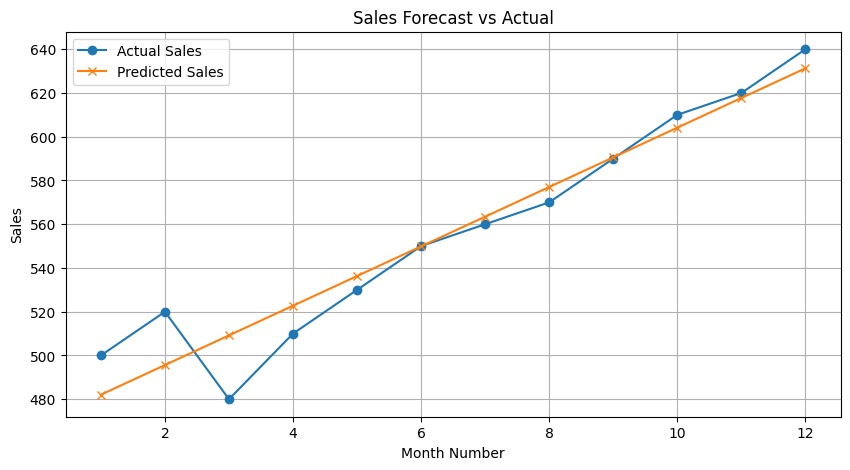

Future Forecast: [644.84848485 658.41491841 671.98135198]
EOQ: 817.312669668102
MAE: 9.883449883449885
RMSE: 13.378420272294072


In [4]:
# sample sales data of 12 months
sales_data = pd.DataFrame({
    'Month': pd.date_range(start='2023-01-01', periods=12, freq='M'),
    'Sales': [500, 520, 480, 510, 530, 550, 560, 570, 590, 610, 620, 640]
})

ordering_cost = 100  # cost per order
holding_cost = 2     # holding cost per unit per year

inv_model = InventoryManagementModel(sales_data, ordering_cost, holding_cost)
forecast_result = inv_model.forecast_and_eoq(plot=True)

# displaying results
print("Future Forecast:", forecast_result['Forecast'])
print("EOQ:", forecast_result['EOQ'])
print("MAE:", forecast_result['MAE'])
print("RMSE:", forecast_result['RMSE'])


In [5]:
# facilities and demand points
facilities = ['F1', 'F2', 'F3']
demand_points = ['D1', 'D2', 'D3', 'D4']

# capacities and fixed costs
capacities = {'F1': 500, 'F2': 600, 'F3': 400}
fixed_costs = {'F1': 10000, 'F2': 12000, 'F3': 8000}

# demands at each point
demands = {'D1': 200, 'D2': 300, 'D3': 250, 'D4': 400}

# transportation cost matrix
transport_costs = pd.DataFrame({
    'D1': [4, 6, 9],
    'D2': [5, 4, 7],
    'D3': [6, 3, 4],
    'D4': [8, 5, 6]
}, index=['F1', 'F2', 'F3'])

# create and solve the model
net_model = NetworkDesignModel(facilities, demand_points, transport_costs, fixed_costs, capacities, demands)
solution = net_model.solve()

# displaying results
print("Status:", solution['Status'])
print("Open Facilities:", solution['OpenFacilities'])
print("Shipments:")
for k, v in solution['Shipments'].items():
    if v > 0:
        print(f"  {k}: {v}")


Status: Optimal
Open Facilities: {'F1': 1.0, 'F2': 1.0, 'F3': 1.0}
Shipments:
  ('F1', 'D1'): 200.0
  ('F1', 'D2'): 300.0
  ('F2', 'D3'): 250.0
  ('F2', 'D4'): 350.0
  ('F3', 'D4'): 50.0


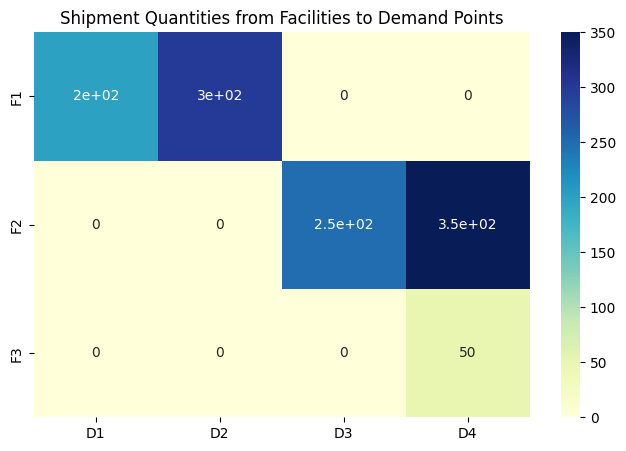

In [6]:
import seaborn as sns

shipment_data = pd.DataFrame(
    0, index=facilities, columns=demand_points
)
for (f, d), val in solution['Shipments'].items():
    shipment_data.loc[f, d] = val

plt.figure(figsize=(8, 5))
sns.heatmap(shipment_data, annot=True, cmap="YlGnBu")
plt.title("Shipment Quantities from Facilities to Demand Points")
plt.show()
